Who dies early in England, and why? Unpacking the roles of deprivation, geography, ethnicity and socioeconomic class in preventable mortality

In [2]:
import pandas as pd

df = pd.read_excel("mortality.xlsx", sheet_name="Table_2", header=4)


print(df.shape)
print(df.columns.tolist())
print(df.head(10))

(17860, 14)
['Condition Group', 'Condition', 'Sex', 'Domain', 'Group', 'Number Of Deaths', 'Population', 'Crude Rate Per 100,000 Person Years', 'Crude Rate Per 100,000 Person Years 95% Lower Confidence Limit', 'Crude Rate Per 100,000 Person Years 95% Upper Confidence Limit', 'Age-Standardised Rate Per 100,000 Person Years', 'Age-Standardised Rate Per 100,000 Person Years 95% Lower Confidence Limit', 'Age-Standardised Rate Per 100,000 Person Years 95% Upper Confidence Limit', 'Notes']
       Condition Group            Condition         Sex        Domain  \
0  All Cause Mortality  All Cause Mortality  All People    All People   
1  All Cause Mortality  All Cause Mortality  All People  Ethnic Group   
2  All Cause Mortality  All Cause Mortality  All People  Ethnic Group   
3  All Cause Mortality  All Cause Mortality  All People  Ethnic Group   
4  All Cause Mortality  All Cause Mortality  All People  Ethnic Group   
5  All Cause Mortality  All Cause Mortality  All People  Ethnic Group   


In [3]:
deprivation = df[
    (df['Domain'] == 'Index of Multiple Deprivation Decile') &
    (df['Sex'] == 'All People')
].copy()

deprivation_clean = deprivation[[
    'Condition',
    'Group',
    'Age-Standardised Rate Per 100,000 Person Years'
]].copy()

deprivation_clean.columns = ['Condition', 'Deprivation_Decile', 'ASR']

print(deprivation_clean.shape)
print(deprivation_clean.head(10))

(300, 3)
              Condition   Deprivation_Decile     ASR
11  All Cause Mortality    1 (Most Deprived)    1430
12  All Cause Mortality                    2  1265.2
13  All Cause Mortality                    3  1162.3
14  All Cause Mortality                    4  1073.1
15  All Cause Mortality                    5   999.2
16  All Cause Mortality                    6   947.5
17  All Cause Mortality                    7   913.9
18  All Cause Mortality                    8   880.4
19  All Cause Mortality                    9   838.8
20  All Cause Mortality  10 (Least Deprived)   769.5


In [4]:
# Check exact unique values in Sex and Domain columns
print(df['Sex'].unique())
print(df['Domain'].unique())

<StringArray>
['All People', 'Female', 'Male']
Length: 3, dtype: str
<StringArray>
[                                      'All People',
                                     'Ethnic Group',
             'Index of Multiple Deprivation Decile',
 'National Statistics Socioeconomic Classification',
                                           'Region',
                       'Upper Tier Local Authority']
Length: 6, dtype: str


In [5]:
print(deprivation_clean['Condition'].unique())

<StringArray>
[                         'All Cause Mortality',
                               'Bladder Cancer',
                                 'Blood Cancer',
                                'Brain Tumours',
                                'Breast Cancer',
                            'Colorectal Cancer',
                           'Head & Neck Cancer',
                                'Kidney Cancer',
                 'Liver & Biliary Tract Cancer',
                                  'Lung Cancer',
                   'Malignant Melanoma Of Skin',
                                 'Mesothelioma',
                            'Pancreatic Cancer',
                 'Stomach & Oesophageal Cancer',
                               'Thyroid Cancer',
 'Aortic Disease & Peripheral Arterial Disease',
                          'Atrial Fibrillation',
                               'Cardiac Arrest',
              'Chronic Ischaemic Heart Disease',
                                'Heart Failure',
      

In [6]:
# Get most and least deprived only
most = deprivation_clean[deprivation_clean['Deprivation_Decile'] == '1 (Most Deprived)'].copy()
least = deprivation_clean[deprivation_clean['Deprivation_Decile'] == '10 (Least Deprived)'].copy()

# Merge them
gap = most.merge(least, on='Condition', suffixes=('_Most', '_Least'))

# Calculate the gap and ratio
gap['Absolute_Gap'] = gap['ASR_Most'] - gap['ASR_Least']
gap['Rate_Ratio'] = (gap['ASR_Most'] / gap['ASR_Least']).round(2)

# Sort by biggest gap
gap_sorted = gap[['Condition', 'ASR_Most', 'ASR_Least', 'Absolute_Gap', 'Rate_Ratio']]\
    .sort_values('Rate_Ratio', ascending=False)

print(gap_sorted.to_string())

                                       Condition ASR_Most ASR_Least Absolute_Gap Rate_Ratio
27         Chronic Obstructive Pulmonary Disease    241.8      51.6        190.2       4.69
9                                    Lung Cancer    110.8      31.6         79.2       3.51
26                                        Asthma       17       5.7         11.3       2.98
25                                      Diabetes    204.4      71.1        133.3       2.87
6                             Head & Neck Cancer     13.9       5.4          8.5       2.57
17                                Cardiac Arrest     16.6       6.5         10.1       2.55
28                                      Covid-19     93.4      38.2         55.2       2.45
18               Chronic Ischaemic Heart Disease    249.9     108.3        141.6       2.31
15  Aortic Disease & Peripheral Arterial Disease     49.3      21.4         27.9        2.3
21                         Myocardial Infarction     68.6      29.9         38.7

## Finding 1: The Deprivation-Mortality Gap
COPD shows the strongest deprivation gradient (4.69x), followed by Lung Cancer (3.51x) 
and Asthma (2.98x). Malignant Melanoma shows a reverse gradient — wealthier areas have 
higher mortality rates (0.67x), likely reflecting greater sun exposure through foreign holidays.

In [7]:
ethnicity = df[
    (df['Domain'] == 'Ethnic Group') &
    (df['Sex'] == 'All People')
].copy()

ethnicity_clean = ethnicity[[
    'Condition',
    'Group',
    'Age-Standardised Rate Per 100,000 Person Years'
]].copy()

ethnicity_clean.columns = ['Condition', 'Ethnicity', 'ASR']

# ASR can contain non-numeric placeholders (e.g. ':', '-', '*') for suppressed values
ethnicity_clean['ASR'] = pd.to_numeric(ethnicity_clean['ASR'], errors='coerce')

# Compare to White British as baseline
white_british = ethnicity_clean[ethnicity_clean['Ethnicity'] == 'White British'][['Condition', 'ASR']].copy()
white_british.columns = ['Condition', 'ASR_WhiteBritish']

ethnicity_merged = ethnicity_clean.merge(white_british, on='Condition')
ethnicity_merged['Rate_Ratio'] = (ethnicity_merged['ASR'] / ethnicity_merged['ASR_WhiteBritish']).round(2)

# Show conditions where Bangladeshi community has highest ratio
bangladeshi = ethnicity_merged[ethnicity_merged['Ethnicity'] == 'Bangladeshi']\
    .sort_values('Rate_Ratio', ascending=False)

print(bangladeshi[['Condition', 'ASR', 'ASR_WhiteBritish', 'Rate_Ratio']].to_string())

                                        Condition    ASR  ASR_WhiteBritish  Rate_Ratio
260                                        Asthma   36.7               9.3        3.95
250                                      Diabetes  422.5             113.1        3.74
230                        Chronic Kidney Disease  224.1              89.4        2.51
280                                      Covid-19  119.9              53.5        2.24
210                         Myocardial Infarction   86.6              42.4        2.04
200                         Hypertensive Diseases  270.7             133.8        2.02
80                   Liver & Biliary Tract Cancer   23.7              12.2        1.94
170                                Cardiac Arrest   16.1               9.7        1.66
220                                        Stroke  149.8              95.5        1.57
180               Chronic Ischaemic Heart Disease  221.7             154.2        1.44
290                                     Pne

## Finding 2: Ethnicity & Condition-Specific Mortality
Bangladeshi communities show lower all-cause mortality than White British (0.94x) — 
consistent with the Healthy Immigrant Effect — but face dramatically higher mortality 
from Diabetes (3.74x) and Asthma (3.95x), suggesting condition-specific vulnerabilities 
rather than general health disadvantage.

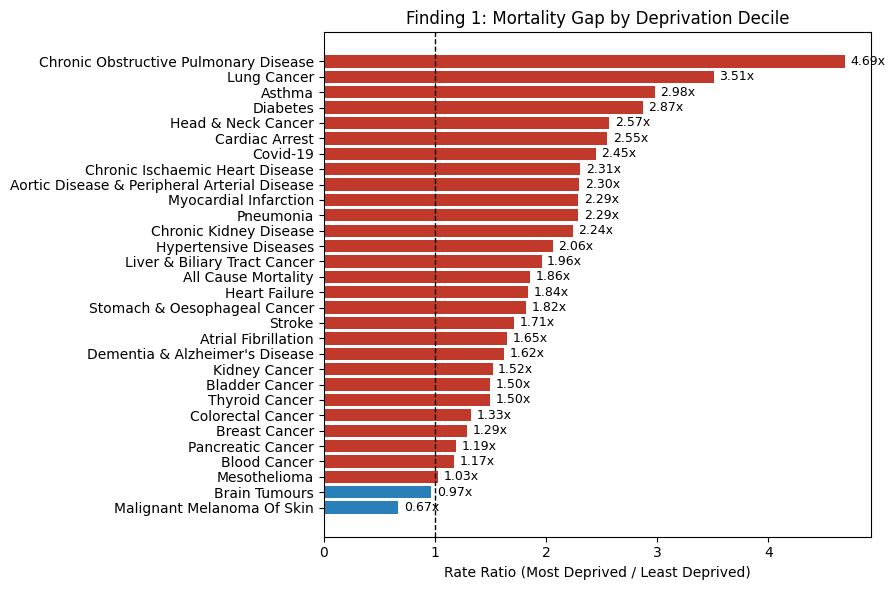

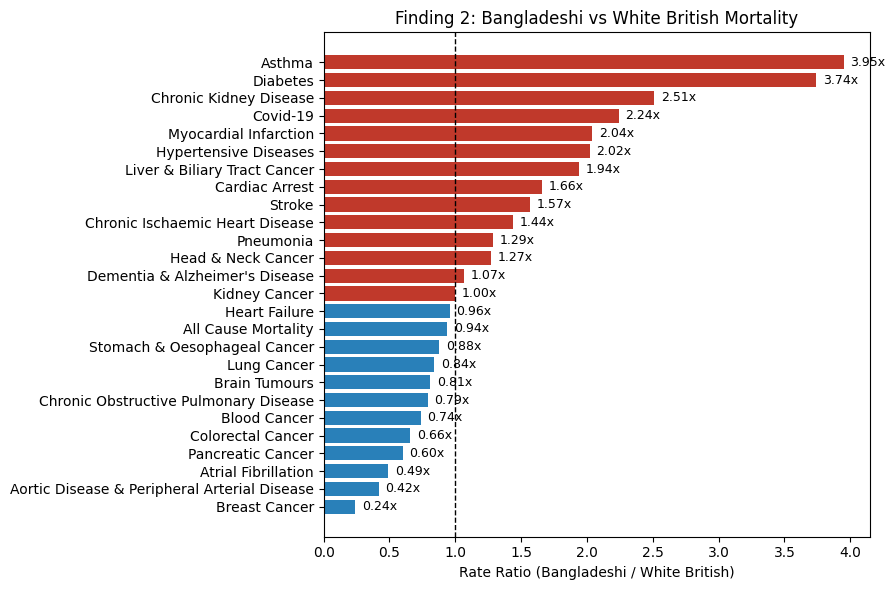

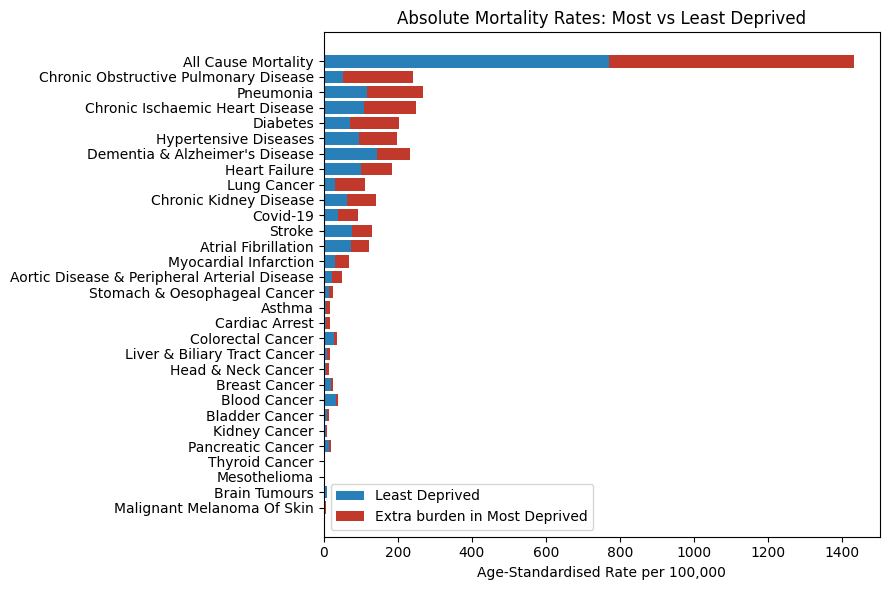

In [8]:
import matplotlib.pyplot as plt

# --- Chart 1: Deprivation gap (Rate Ratio: Most vs Least deprived) ---
fig, ax = plt.subplots(figsize=(9, 6))
plot_df = gap_sorted.sort_values('Rate_Ratio')
colors = ['#c0392b' if r >= 1 else '#2980b9' for r in plot_df['Rate_Ratio']]
ax.barh(plot_df['Condition'], plot_df['Rate_Ratio'], color=colors)
ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Rate Ratio (Most Deprived / Least Deprived)')
ax.set_title('Finding 1: Mortality Gap by Deprivation Decile')
for y, v in enumerate(plot_df['Rate_Ratio']):
    ax.text(v + 0.05, y, f'{v:.2f}x', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# --- Chart 2: Bangladeshi vs White British mortality ratios ---
fig, ax = plt.subplots(figsize=(9, 6))
bang_plot = bangladeshi.dropna(subset=['Rate_Ratio']).sort_values('Rate_Ratio')
colors = ['#c0392b' if r >= 1 else '#2980b9' for r in bang_plot['Rate_Ratio']]
ax.barh(bang_plot['Condition'], bang_plot['Rate_Ratio'], color=colors)
ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Rate Ratio (Bangladeshi / White British)')
ax.set_title('Finding 2: Bangladeshi vs White British Mortality')
for y, v in enumerate(bang_plot['Rate_Ratio']):
    ax.text(v + 0.05, y, f'{v:.2f}x', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# --- Chart 3: Absolute mortality rates (Most vs Least deprived) ---
fig, ax = plt.subplots(figsize=(9, 6))
plot_df = gap_sorted.sort_values('Absolute_Gap')
y = range(len(plot_df))
ax.barh(y, plot_df['ASR_Least'], color='#2980b9', label='Least Deprived')
ax.barh(y, plot_df['ASR_Most'] - plot_df['ASR_Least'],
        left=plot_df['ASR_Least'], color='#c0392b', label='Extra burden in Most Deprived')
ax.set_yticks(list(y))
ax.set_yticklabels(plot_df['Condition'])
ax.set_xlabel('Age-Standardised Rate per 100,000')
ax.set_title('Absolute Mortality Rates: Most vs Least Deprived')
ax.legend()
plt.tight_layout()
plt.show()


In [9]:
df4 = pd.read_excel("mortality.xlsx", sheet_name="Table_4", header=4)
print(df4.shape)
print(df4.columns.tolist())
df4.describe()

(1800, 14)
['Condition Group', 'Condition', 'Sex', 'Ethnic Group', 'Index Of Multiple Deprivation Quintile', 'Number Of Deaths', 'Population', 'Crude Rate Per 100,000 Person Years', 'Crude Rate Per 100,000 Person Years 95% Lower Confidence Limit', 'Crude Rate Per 100,000 Person Years 95% Upper Confidence Limit', 'Age-Standardised Rate Per 100,000 Person Years', 'Age-Standardised Rate Per 100,000 Person Years 95% Lower Confidence Limit', 'Age-Standardised Rate Per 100,000 Person Years 95% Upper Confidence Limit', 'Notes']


,Condition Group,Condition,Sex,Ethnic Group,Index Of Multiple Deprivation Quintile,Number Of Deaths,Population,"Crude Rate Per 100,000 Person Years","Crude Rate Per 100,000 Person Years 95% Lower Confidence Limit","Crude Rate Per 100,000 Person Years 95% Upper Confidence Limit","Age-Standardised Rate Per 100,000 Person Years","Age-Standardised Rate Per 100,000 Person Years 95% Lower Confidence Limit","Age-Standardised Rate Per 100,000 Person Years 95% Upper Confidence Limit",Notes
count,1800,1800,1800,1800,1800,1800,1800,1800,1800,1800,1800,1800,1800,1800
unique,7,35,3,10,5,323,130,620,584,678,864,810,939,2
top,Cancers,Breast Cancer,All People,Bangladeshi,1 (Most Deprived),[c],[c],[c],[c],[c],[c],[c],[c],[2][3][4][5]
freq,1000,100,1500,180,360,472,472,472,472,472,472,472,472,1637


In [10]:
print(df4['Ethnic Group'].unique())
print(df4['Index Of Multiple Deprivation Quintile'].unique())
print(df4['Sex'].unique())


<StringArray>
[    'Bangladeshi',   'Black African', 'Black Caribbean',         'Chinese',
          'Indian',           'Mixed',           'Other',       'Pakistani',
   'White British',     'White other']
Length: 10, dtype: str
<StringArray>
['1 (Most Deprived)', '2', '3', '4', '5 (Least Deprived)']
Length: 5, dtype: str
<StringArray>
['All People', 'Female', 'Male']
Length: 3, dtype: str


In [11]:
# Filter to Diabetes, All People
diabetes = df4[
    (df4['Condition'] == 'Diabetes') &
    (df4['Sex'] == 'All People')
].copy()

# Convert ASR to numeric
diabetes['ASR'] = pd.to_numeric(
    diabetes['Age-Standardised Rate Per 100,000 Person Years'], 
    errors='coerce'
)

# Keep only what we need
diabetes_clean = diabetes[[
    'Ethnic Group', 
    'Index Of Multiple Deprivation Quintile', 
    'ASR'
]].copy()

# Pivot so ethnic groups are rows, deprivation quintiles are columns
diabetes_pivot = diabetes_clean.pivot(
    index='Ethnic Group', 
    columns='Index Of Multiple Deprivation Quintile', 
    values='ASR'
)

print(diabetes_pivot.to_string())

Index Of Multiple Deprivation Quintile  1 (Most Deprived)      2      3      4  5 (Least Deprived)
Ethnic Group                                                                                      
Bangladeshi                                         472.7  407.1  413.3  322.0               379.4
Black African                                       139.9  142.2  175.1  137.6               105.6
Black Caribbean                                     278.1  250.4  217.0  198.2               216.1
Chinese                                             145.6  112.4  126.3  102.2                86.8
Indian                                              310.3  267.6  237.5  209.1               173.0
Mixed                                               166.6  172.4  130.8  147.6               109.9
Other                                               206.2  200.1  179.1  139.0               122.6
Pakistani                                           361.3  349.0  313.7  249.5               222.1
White Brit

## Finding 3: Deprivation Does Not Explain South Asian Diabetes Mortality
Bangladeshi communities in the least deprived quintile (ASR: 379.4) face over 5x higher 
diabetes mortality than White British in the same quintile (ASR: 75.5). This rules out 
deprivation as the primary driver and points to structural, genetic, or cultural factors 
requiring targeted intervention beyond poverty reduction alone.

In [12]:
df3 = pd.read_excel("mortality.xlsx", sheet_name="Table_3", header=4)
print(df3.shape)
print(df3.columns.tolist())
print(df3['Domain'].unique())

(21660, 15)
['Condition Group', 'Condition', 'Sex', 'Domain', 'Group', 'Age Group', 'Number Of Deaths', 'Population', 'Crude Rate Per 100,000 Person Years', 'Crude Rate Per 100,000 Person Years 95% Lower Confidence Limit', 'Crude Rate Per 100,000 Person Years 95% Upper Confidence Limit', 'Age-Standardised Rate Per 100,000 Person Years', 'Age-Standardised Rate Per 100,000 Person Years 95% Lower Confidence Limit', 'Age-Standardised Rate Per 100,000 Person Years 95% Upper Confidence Limit', 'Notes']
<StringArray>
[                                      'All People',
                                     'Ethnic Group',
             'Index of Multiple Deprivation Decile',
 'National Statistics Socioeconomic Classification',
                                           'Region']
Length: 5, dtype: str


In [13]:
# Filter to Region domain and check groups
regions = df3[df3['Domain'] == 'Region']
print(regions['Group'].unique())
print(regions['Age Group'].unique())

<StringArray>
[           'East Midlands',          'East of England',
                   'London',               'North East',
               'North West',               'South East',
               'South West',            'West Midlands',
 'Yorkshire and The Humber']
Length: 9, dtype: str
<StringArray>
['<40', '40-49', '50-59', '60-69', '70-79', '80+']
Length: 6, dtype: str


In [14]:
# Convert ASR to numeric first
df3['Age-Standardised Rate Per 100,000 Person Years'] = pd.to_numeric(
    df3['Age-Standardised Rate Per 100,000 Person Years'], 
    errors='coerce'
)

# Filter to Region and All People
regional = df3[
    (df3['Domain'] == 'Region') &
    (df3['Sex'] == 'All People')
].copy()

# Use Number of Deaths and Population to calculate overall rate per region per condition
regional['Number Of Deaths'] = pd.to_numeric(regional['Number Of Deaths'], errors='coerce')
regional['Population'] = pd.to_numeric(regional['Population'], errors='coerce')

# Aggregate across age groups
regional_agg = regional.groupby(['Condition', 'Group']).agg(
    Total_Deaths=('Number Of Deaths', 'sum'),
    Total_Population=('Population', 'sum')
).reset_index()

# Calculate crude rate
regional_agg['Rate_Per_100k'] = (
    regional_agg['Total_Deaths'] / regional_agg['Total_Population'] * 100000
).round(1)

# Pivot to see regions as columns
regional_pivot = regional_agg.pivot(
    index='Condition',
    columns='Group',
    values='Rate_Per_100k'
)

print(regional_pivot.to_string())

Group                                         East Midlands  East of England  London  North East  North West  South East  South West  West Midlands  Yorkshire and The Humber
Condition                                                                                                                                                                    
All Cause Mortality                                  1838.4           1737.8  1058.1      2040.8      1890.9      1710.1      1980.6         1826.3                    1863.8
Aortic Disease & Peripheral Arterial Disease          121.8             54.0    33.2       114.9        55.0        54.4        62.7           57.0                      62.0
Asthma                                                 20.1             20.6    13.5        32.4        14.7        14.4        11.9           23.7                      19.8
Atrial Fibrillation                                   346.2            354.2   235.6       335.3       287.2       409.2       329

## Finding 4: The North-South Mortality Divide Is Real and Severe
The North East shows consistently the highest mortality across most conditions. 
All-cause mortality (2,040) is nearly double London's (1,058). COPD and Lung Cancer 
show the starkest gradients, likely reflecting industrial heritage, smoking rates, 
and socioeconomic deprivation concentrated in the region.